In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F

In [13]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
# Load Dataset (MNIST-like)
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.MNIST(root="data", train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [15]:
images, labels = next(iter(dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


In [16]:
latent_dim = 24

In [17]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim=28*28, latent_dim=64):
        super(VariationalAutoencoder, self).__init__()

        # Shared encoder
        self.encoder_fc1 = nn.Linear(input_dim, 256)
        self.encoder_fc2 = nn.Linear(256, 128)

        # Latent space mappings
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_var = nn.Linear(128, latent_dim)

        # Decoder
        self.decode = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = F.leaky_relu(self.encoder_fc1(x), 0.2)
        hidden = F.leaky_relu(self.encoder_fc2(x), 0.2)
        mu = self.fc_mu(hidden)
        logvar = self.fc_var(hidden)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        decoded = self.decode(z)
        return decoded, mu, logvar

In [18]:
def vae_loss(reconstructed, original, mu, logvar):
    BCE = F.binary_cross_entropy(reconstructed, original, reduction='sum') / original.size(0)
    KLD = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return BCE + KLD, BCE.item(), KLD.item()

In [19]:
# Initialize Model
vae = VariationalAutoencoder(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# Training Loop
num_epochs = 300
recon_losses, kl_losses, total_losses = [], [], []

for epoch in range(num_epochs):
    epoch_recon, epoch_kl = 0, 0
    vae.train()
    for images, _ in dataloader:
        images = images.view(images.size(0), -1).to(device)
        reconstructed, mu, logvar = vae(images)

        loss, recon_loss, kl_loss = vae_loss(reconstructed, images, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_recon += recon_loss
        epoch_kl += kl_loss

    avg_recon = epoch_recon / len(dataloader)
    avg_kl = epoch_kl / len(dataloader)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)
    total_losses.append(avg_recon + avg_kl)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Total: {avg_recon + avg_kl:.4f}, Recon: {avg_recon:.4f}, KL: {avg_kl:.4f}")

print("Training complete!")

Epoch [1/300] - Total: 164.1930, Recon: 153.1260, KL: 11.0670
Epoch [2/300] - Total: 123.0973, Recon: 105.2548, KL: 17.8425
Epoch [3/300] - Total: 115.4458, Recon: 96.0888, KL: 19.3570
Epoch [4/300] - Total: 111.9219, Recon: 91.7520, KL: 20.1699
Epoch [5/300] - Total: 109.9090, Recon: 89.2788, KL: 20.6302
Epoch [6/300] - Total: 108.3386, Recon: 87.3243, KL: 21.0143
Epoch [7/300] - Total: 107.2524, Recon: 86.0222, KL: 21.2302
Epoch [8/300] - Total: 106.3568, Recon: 84.9473, KL: 21.4095
Epoch [9/300] - Total: 105.6992, Recon: 84.1324, KL: 21.5668
Epoch [10/300] - Total: 105.1448, Recon: 83.4962, KL: 21.6486
Epoch [11/300] - Total: 104.6274, Recon: 82.9326, KL: 21.6948
Epoch [12/300] - Total: 104.2001, Recon: 82.4159, KL: 21.7841
Epoch [13/300] - Total: 103.8948, Recon: 82.0496, KL: 21.8452
Epoch [14/300] - Total: 103.5414, Recon: 81.6545, KL: 21.8869
Epoch [15/300] - Total: 103.2462, Recon: 81.3467, KL: 21.8995
Epoch [16/300] - Total: 103.0010, Recon: 81.0308, KL: 21.9702
Epoch [17/300] 

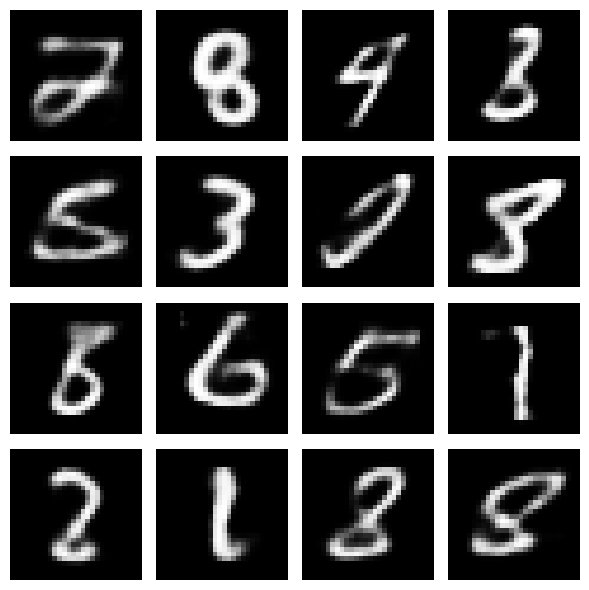

In [20]:
# Generate New Samples
vae.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated = vae.decode(z).cpu().view(-1, 1, 28, 28)

# Plot Generated Samples
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].squeeze(), cmap="gray")
    ax.axis('off')
plt.tight_layout()
plt.show()

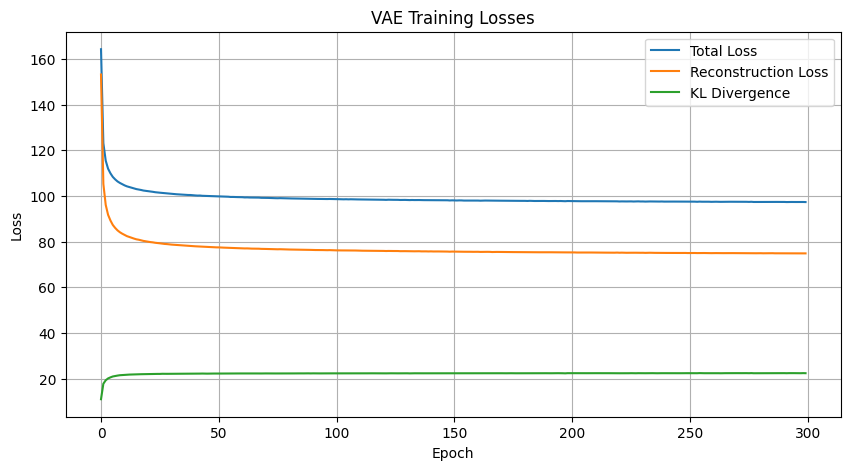

In [21]:
# Plot Training Losses
plt.figure(figsize=(10, 5))
plt.plot(total_losses, label='Total Loss')
plt.plot(recon_losses, label='Reconstruction Loss')
plt.plot(kl_losses, label='KL Divergence')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("VAE Training Losses")
plt.grid(True)
plt.show()

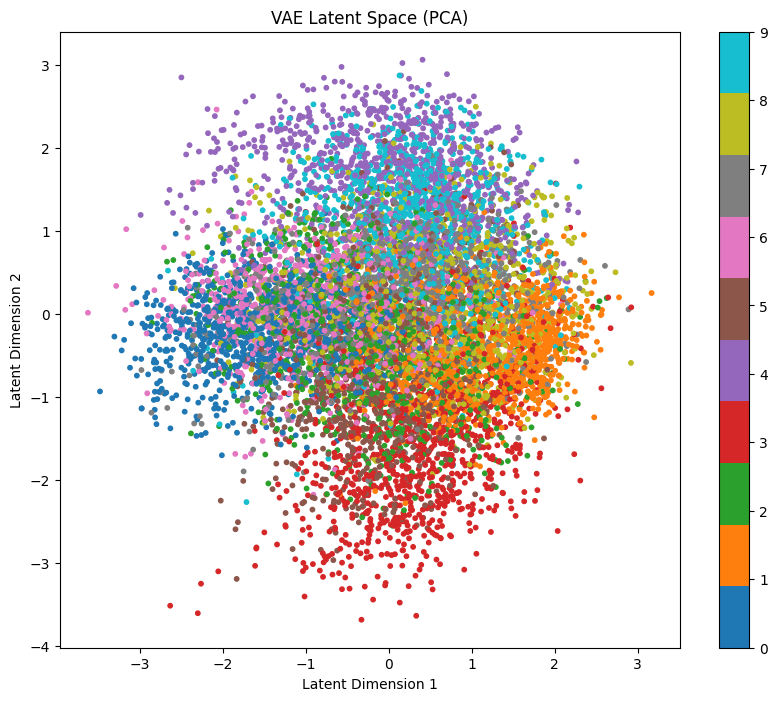

In [22]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torchvision import datasets
from torch.utils.data import DataLoader
import numpy as np

# Load the test set
test_dataset = datasets.MNIST(root='data', train=False, transform=transforms.ToTensor(), download=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

# Encode the test set images to latent space
vae.eval()
latent_representations = []
labels = []

with torch.no_grad():
    for images, target in test_loader:
        images = images.view(images.size(0), -1).to(device)
        mu, _ = vae.encode(images)  # Get mean (mu) for each sample in the batch
        latent_representations.append(mu.cpu().numpy())  # Store latent variables
        labels.append(target.numpy())  # Store corresponding labels

# Flatten the list of latent representations and labels
latent_representations = np.concatenate(latent_representations, axis=0)
labels = np.concatenate(labels, axis=0)

# Reduce to 2D using PCA or t-SNE
pca = PCA(n_components=2)
latent_2d_pca = pca.fit_transform(latent_representations)

# Visualize the 2D latent space
plt.figure(figsize=(10, 8))
plt.scatter(latent_2d_pca[:, 0], latent_2d_pca[:, 1], c=labels, cmap='tab10', s=10)
plt.colorbar()
plt.title("VAE Latent Space (PCA)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.show()
